# 🔬 OncosenseAI — Module 2: Visual AI Diagnostics
> **Approach:** Rule-based image analysis using OpenCV + colour detection  
> **No API key needed — runs entirely in Colab**
> ⚠️ Research Prototype Only. Not validated for clinical use.
---
### Pipeline
```
Upload image → OpenCV colour + texture analysis → Concern Level → module2_output.json
```
Run cells one by one top to bottom.

In [1]:
# Cell 1 — Install dependencies
!pip install opencv-python-headless pillow numpy matplotlib -q

import cv2
import numpy as np
import json
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files
from pathlib import Path
from IPython.display import display
import io

print('✅ Dependencies loaded — no API key needed')

✅ Dependencies loaded — no API key needed


In [2]:
# Cell 2 — Colour analysis utilities

def load_image(image_path):
    img_bgr = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    return img_bgr, img_rgb, img_hsv, img_lab


def get_dominant_colour(img_rgb, k=3):
    pixels = img_rgb.reshape(-1, 3).astype(np.float32)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 20, 1.0)
    _, labels, centres = cv2.kmeans(pixels, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
    counts = np.bincount(labels.flatten())
    dominant = centres[np.argmax(counts)].astype(int)
    return tuple(dominant)  # RGB


def pixel_fraction(img_hsv, lower, upper):
    mask = cv2.inRange(img_hsv, np.array(lower), np.array(upper))
    return np.sum(mask > 0) / mask.size


def describe_rgb(r, g, b):
    if r > 150 and g < 100 and b < 100:
        return 'red'
    elif r < 60 and g < 60 and b < 60:
        return 'black'
    elif r > 100 and g > 80 and b < 60:
        return 'brown'
    elif r > 180 and g > 150 and b < 80:
        return 'yellow-amber'
    elif r > 200 and g > 200 and b > 200:
        return 'pale/white'
    elif r > 120 and g > 100 and b < 70:
        return 'dark-brown'
    elif r > 150 and g > 150 and b < 100:
        return 'amber'
    else:
        return f'mixed (R:{r} G:{g} B:{b})'


def show_image(image_path, title=''):
    img = Image.open(image_path)
    plt.figure(figsize=(5, 4))
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.show()


print('✅ Colour utilities loaded')

✅ Colour utilities loaded


In [3]:
# Cell 3 — Image analysers (one per image type)

def analyse_stool(image_path):
    img_bgr, img_rgb, img_hsv, img_lab = load_image(image_path)
    dom_r, dom_g, dom_b = get_dominant_colour(img_rgb)
    colour_desc = describe_rgb(dom_r, dom_g, dom_b)

    # Detect red (bright blood)
    red_frac = pixel_fraction(img_hsv, [0, 100, 100], [10, 255, 255])
    red_frac += pixel_fraction(img_hsv, [170, 100, 100], [180, 255, 255])

    # Detect black/very dark (melanotic — upper GI bleed)
    dark_frac = pixel_fraction(img_hsv, [0, 0, 0], [180, 255, 50])

    # Detect pale/clay (biliary obstruction)
    pale_frac = pixel_fraction(img_hsv, [0, 0, 180], [180, 30, 255])

    # Blood detection
    blood_visible = red_frac > 0.05
    blood_char = 'none'
    if red_frac > 0.05:
        blood_char = 'bright_red'
    elif dark_frac > 0.4:
        blood_char = 'melanotic'

    # Concern level
    concern = 'Low'
    rationale = 'No significant abnormal features detected.'
    action = 'Routine follow-up'

    if blood_char == 'bright_red':
        concern = 'High'
        rationale = 'Visible red blood detected — may indicate lower GI bleeding or colorectal pathology.'
        action = 'Urgent referral — colonoscopy recommended'
    elif blood_char == 'melanotic':
        concern = 'High'
        rationale = 'Dark/melanotic stool detected — may indicate upper GI bleeding.'
        action = 'Urgent referral — upper GI endoscopy recommended'
    elif pale_frac > 0.5 and colour_desc in ['pale/white']:
        concern = 'Moderate'
        rationale = 'Pale/clay-coloured stool — may suggest biliary obstruction or hepatic pathology.'
        action = 'LFTs + abdominal ultrasound recommended'
    elif colour_desc in ['brown', 'dark-brown']:
        concern = 'Low'
        rationale = 'Normal brown coloration. No obvious abnormal features.'
        action = 'Routine follow-up'

    # Bristol scale estimate from texture
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    laplacian_var = cv2.Laplacian(gray, cv2.CV_64F).var()
    bristol = 4  # default normal
    if laplacian_var < 50:
        bristol = 6  # loose/mushy
    elif laplacian_var > 500:
        bristol = 2  # hard/lumpy

    return {
        'image_type': 'stool',
        'image_quality': 'good',
        'colour': {'observed': colour_desc, 'clinically_significant': concern != 'Low', 'notes': f'Dominant RGB: ({dom_r},{dom_g},{dom_b})'},
        'consistency': {'observed': 'estimated from texture', 'bristol_scale_estimate': bristol, 'notes': f'Texture variance: {laplacian_var:.1f}'},
        'blood': {'visible': blood_visible, 'character': blood_char, 'notes': f'Red pixel fraction: {red_frac:.3f}'},
        'abnormal_features': ['melanotic appearance'] if blood_char == 'melanotic' else [],
        'concern_level': concern,
        'concern_rationale': rationale,
        'recommended_action': action
    }


def analyse_urine(image_path):
    img_bgr, img_rgb, img_hsv, img_lab = load_image(image_path)
    dom_r, dom_g, dom_b = get_dominant_colour(img_rgb)
    colour_desc = describe_rgb(dom_r, dom_g, dom_b)

    # Red/pink (haematuria)
    red_frac = pixel_fraction(img_hsv, [0, 50, 100], [15, 255, 255])
    red_frac += pixel_fraction(img_hsv, [165, 50, 100], [180, 255, 255])

    # Dark amber/brown (bilirubinuria, concentrated)
    amber_frac = pixel_fraction(img_hsv, [10, 80, 80], [30, 255, 255])

    # Pale/clear (normal/dilute)
    pale_frac = pixel_fraction(img_hsv, [20, 0, 200], [60, 60, 255])

    # Froth estimate — high contrast in upper region
    h, w = img_bgr.shape[:2]
    top_region = img_bgr[:h//4, :]
    top_gray = cv2.cvtColor(top_region, cv2.COLOR_BGR2GRAY)
    froth_score = cv2.Laplacian(top_gray, cv2.CV_64F).var()
    froth_present = froth_score > 200

    haematuria = red_frac > 0.05
    bilirubinuria = amber_frac > 0.3 and colour_desc in ['amber', 'dark-brown', 'yellow-amber']

    concern = 'Low'
    rationale = 'Normal urine appearance.'
    action = 'Routine follow-up'

    if haematuria:
        concern = 'High'
        rationale = 'Red/pink discolouration detected — possible haematuria indicating urological or renal pathology.'
        action = 'Urgent urine dipstick + renal/urological referral'
    elif bilirubinuria:
        concern = 'High'
        rationale = 'Dark amber/brown urine detected — possible bilirubinuria suggesting hepatic or biliary obstruction.'
        action = 'Urgent LFTs + abdominal ultrasound + hepatology review'
    elif froth_present:
        concern = 'Moderate'
        rationale = 'Frothy appearance detected — may indicate proteinuria requiring further investigation.'
        action = 'Urine dipstick for protein + renal function tests'
    elif colour_desc in ['pale/white']:
        concern = 'Low'
        rationale = 'Pale/dilute urine — likely well hydrated, no significant abnormality.'
        action = 'Routine follow-up'

    return {
        'image_type': 'urine',
        'image_quality': 'good',
        'colour': {'observed': colour_desc, 'clinically_significant': concern != 'Low', 'notes': f'Dominant RGB: ({dom_r},{dom_g},{dom_b})'},
        'clarity': {'observed': 'clear' if pale_frac > 0.3 else 'turbid', 'notes': f'Pale fraction: {pale_frac:.3f}'},
        'froth': {'present': froth_present, 'notes': f'Froth score: {froth_score:.1f}'},
        'visible_blood': {'present': haematuria, 'notes': f'Red fraction: {red_frac:.3f}'},
        'bilirubinuria_signs': {'suspected': bilirubinuria, 'notes': f'Amber fraction: {amber_frac:.3f}'},
        'concern_level': concern,
        'concern_rationale': rationale,
        'recommended_action': action
    }


def analyse_abdomen(image_path):
    img_bgr, img_rgb, img_hsv, img_lab = load_image(image_path)
    dom_r, dom_g, dom_b = get_dominant_colour(img_rgb)
    colour_desc = describe_rgb(dom_r, dom_g, dom_b)

    # Jaundice — yellow skin tone (high R+G, low B in LAB space)
    l_chan, a_chan, b_chan = cv2.split(img_lab)
    yellow_mask = (b_chan > 135) & (a_chan < 135) & (l_chan > 100)
    jaundice_frac = np.sum(yellow_mask) / yellow_mask.size
    jaundice_visible = jaundice_frac > 0.25

    # Distension — overall roundness/convexity of abdomen shape
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    distension_grade = 'none'
    distension_present = False
    if contours:
        largest = max(contours, key=cv2.contourArea)
        area = cv2.contourArea(largest)
        hull_area = cv2.contourArea(cv2.convexHull(largest))
        solidity = area / hull_area if hull_area > 0 else 0
        img_area = img_bgr.shape[0] * img_bgr.shape[1]
        fill_ratio = area / img_area
        if fill_ratio > 0.7 and solidity > 0.85:
            distension_present = True
            distension_grade = 'moderate'

    concern = 'Low'
    rationale = 'No significant abnormal visual features detected.'
    action = 'Routine follow-up'

    if jaundice_visible and distension_present:
        concern = 'High'
        rationale = 'Jaundice and abdominal distension detected — may indicate hepatic malignancy, biliary obstruction, or ascites.'
        action = 'Urgent hepatology referral + CT abdomen + LFTs'
    elif jaundice_visible:
        concern = 'High'
        rationale = 'Yellow skin discolouration detected — possible jaundice suggesting hepatic or biliary pathology.'
        action = 'Urgent LFTs + abdominal ultrasound + hepatology review'
    elif distension_present:
        concern = 'Moderate'
        rationale = 'Abdominal distension detected — may suggest ascites, bowel obstruction, or intra-abdominal mass.'
        action = 'Abdominal ultrasound + clinical examination'

    return {
        'image_type': 'abdomen',
        'image_quality': 'good',
        'distension': {'present': distension_present, 'grade': distension_grade, 'notes': 'Estimated from contour fill ratio'},
        'ascites_signs': {'suspected': distension_present, 'features_observed': ['generalised distension'] if distension_present else [], 'notes': ''},
        'visible_mass': {'present': False, 'location': 'none', 'notes': 'Requires clinical examination for confirmation'},
        'caput_medusae': {'present': False, 'notes': 'Cannot reliably detect from photograph alone'},
        'skin_changes': {'jaundice_visible': jaundice_visible, 'other': colour_desc, 'notes': f'Yellow fraction: {jaundice_frac:.3f}'},
        'concern_level': concern,
        'concern_rationale': rationale,
        'recommended_action': action
    }


ANALYSERS = {'stool': analyse_stool, 'urine': analyse_urine, 'abdomen': analyse_abdomen}
print('✅ Analysers loaded — stool · urine · abdomen')

✅ Analysers loaded — stool · urine · abdomen


📸 Image Upload & Analysis
No API needed — analysis runs locally in Colab!


----------------------------------------
Upload STOOL image (or Cancel to skip):


Saving Bristol_Stool_Chart2.webp to Bristol_Stool_Chart2.webp


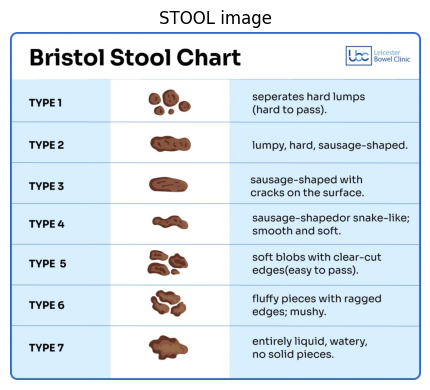


🔍 Analysing stool...
   🟢 Concern: Low
   📋 No significant abnormal features detected.
   → Routine follow-up

----------------------------------------
Upload URINE image (or Cancel to skip):


Saving OIP.webp to OIP.webp


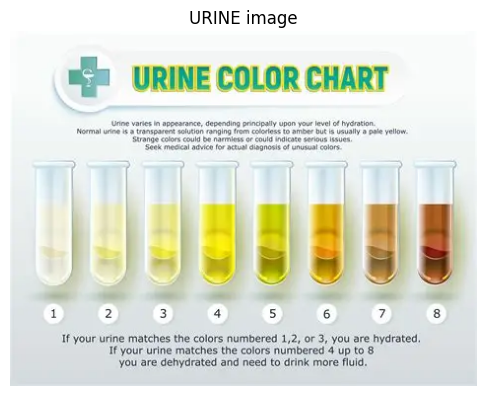


🔍 Analysing urine...
   🟡 Concern: Moderate
   📋 Frothy appearance detected — may indicate proteinuria requiring further investigation.
   → Urine dipstick for protein + renal function tests

----------------------------------------
Upload ABDOMEN image (or Cancel to skip):


Saving OIP (1).webp to OIP (1).webp


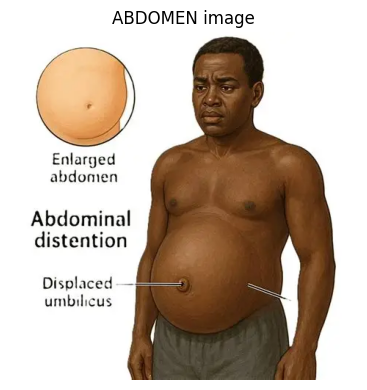


🔍 Analysing abdomen...
   🟢 Concern: Low
   📋 No significant abnormal visual features detected.
   → Routine follow-up

✅ Analysis complete — run Cell 5 for summary


In [4]:
# Cell 4 — Upload and analyse images
# File picker appears for each type — skip any by pressing Cancel

all_findings = {}
concern_scores = {}
IMAGE_TYPES = ['stool', 'urine', 'abdomen']
concern_to_score = lambda l: {'Low': 0.1, 'Moderate': 0.5, 'High': 0.9}.get(l, 0.1)

print('📸 Image Upload & Analysis')
print('=' * 50)
print('No API needed — analysis runs locally in Colab!\n')

for img_type in IMAGE_TYPES:
    print(f'\n{"-" * 40}')
    print(f'Upload {img_type.upper()} image (or Cancel to skip):')
    try:
        uploaded = files.upload()
        if not uploaded:
            print(f'   ⏭️  Skipping {img_type}')
            all_findings[img_type] = {'image_type': img_type, 'provided': False, 'concern_level': 'Low'}
            concern_scores[img_type] = 0.0
            continue
        filename = list(uploaded.keys())[0]
        save_path = f'/tmp/{img_type}_{filename}'
        with open(save_path, 'wb') as f:
            f.write(uploaded[filename])

        # Show image
        show_image(save_path, f'{img_type.upper()} image')

        # Analyse
        print(f'\n🔍 Analysing {img_type}...')
        findings = ANALYSERS[img_type](save_path)
        findings['provided'] = True
        all_findings[img_type] = findings
        concern_scores[img_type] = concern_to_score(findings.get('concern_level', 'Low'))

        emoji = {'Low': '🟢', 'Moderate': '🟡', 'High': '🔴'}.get(findings['concern_level'], '⚪')
        print(f'   {emoji} Concern: {findings["concern_level"]}')
        print(f'   📋 {findings["concern_rationale"]}')
        print(f'   → {findings["recommended_action"]}')

    except Exception as e:
        print(f'   ❌ Error: {e}')
        all_findings[img_type] = {'image_type': img_type, 'provided': False,
                                   'concern_level': 'Low', 'error': str(e)}
        concern_scores[img_type] = 0.0

print(f'\n{"=" * 50}')
print('✅ Analysis complete — run Cell 5 for summary')

In [5]:
# Cell 5 — Summary + save module2_output.json

# Fix: convert numpy types to native Python for JSON serialisation
import numpy as np

def convert(obj):
    if isinstance(obj, (np.bool_,)):
        return bool(obj)
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, dict):
        return {k: convert(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [convert(i) for i in obj]
    return obj

all_findings = convert(all_findings)
concern_scores = convert(concern_scores)

IMAGE_TYPES = ['stool', 'urine', 'abdomen']
emoji_map = {'Low': '🟢', 'Moderate': '🟡', 'High': '🔴'}
concern_rank = {'Low': 0, 'Moderate': 1, 'High': 2}

provided_scores = [concern_scores[t] for t in IMAGE_TYPES if all_findings.get(t, {}).get('provided')]
overall_visual_score = round(sum(provided_scores) / len(provided_scores), 3) if provided_scores else 0.0
provided_concerns = [all_findings[t].get('concern_level', 'Low') for t in IMAGE_TYPES if all_findings.get(t, {}).get('provided')]
highest_concern = max(provided_concerns, key=lambda x: concern_rank.get(x, 0)) if provided_concerns else 'Low'

print('\n' + '=' * 55)
print('  OncosenseAI — Module 2 Visual AI Summary')
print('=' * 55)
for img_type in IMAGE_TYPES:
    f = all_findings.get(img_type, {})
    if f.get('provided'):
        level = f.get('concern_level', 'Low')
        print(f'\n  {img_type.upper():10s}  {emoji_map[level]} {level}')
        print(f'  {" ":10s}  {f.get("concern_rationale", "")}')
        print(f'  {" ":10s}  → {f.get("recommended_action", "")}')
    else:
        print(f'\n  {img_type.upper():10s}  ⚪ Not provided')

print(f'\n{"-" * 55}')
print(f'  Overall Visual Score  : {overall_visual_score:.3f}')
print(f'  Highest Concern Level : {emoji_map.get(highest_concern, "⚪")} {highest_concern}')
print('=' * 55)

module2_output = convert({
    'module': '2_visual_ai',
    'version': '2.1',
    'method': 'rule_based_opencv',
    'images_analysed': [t for t in IMAGE_TYPES if all_findings.get(t, {}).get('provided')],
    'findings': all_findings,
    'concern_scores': concern_scores,
    'overall_visual_score': overall_visual_score,
    'highest_concern_level': highest_concern,
    'module1_integration': {
        'visual_concern_score': overall_visual_score,
        'highest_concern': highest_concern,
        'flag_urgent': highest_concern == 'High',
        'stool_blood_visible': all_findings.get('stool', {}).get('blood', {}).get('visible', False),
        'ascites_suspected': all_findings.get('abdomen', {}).get('ascites_signs', {}).get('suspected', False),
        'jaundice_visible': all_findings.get('abdomen', {}).get('skin_changes', {}).get('jaundice_visible', False),
        'bilirubinuria_suspected': all_findings.get('urine', {}).get('bilirubinuria_signs', {}).get('suspected', False),
        'haematuria': all_findings.get('urine', {}).get('visible_blood', {}).get('present', False)
    }
})

output_path = '/content/module2_output.json'
with open(output_path, 'w') as f:
    json.dump(module2_output, f, indent=2)
print(f'\n✅ Saved: {output_path}')
files.download(output_path)
print('📥 module2_output.json downloaded')



  OncosenseAI — Module 2 Visual AI Summary

  STOOL       🟢 Low
              No significant abnormal features detected.
              → Routine follow-up

  URINE       🟡 Moderate
              Frothy appearance detected — may indicate proteinuria requiring further investigation.
              → Urine dipstick for protein + renal function tests

  ABDOMEN     🟢 Low
              No significant abnormal visual features detected.
              → Routine follow-up

-------------------------------------------------------
  Overall Visual Score  : 0.233
  Highest Concern Level : 🟡 Moderate

✅ Saved: /content/module2_output.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 module2_output.json downloaded


---
## Cell 6 — Module 1 Bridge
Copy into your **Module 1 notebook** and remove the `#` to uncomment.

In [6]:
# Cell 6 — Module 1 bridge (copy into Module 1 and uncomment)
#
# import json
# from google.colab import files
# uploaded = files.upload()
# m2 = json.loads(list(uploaded.values())[0])
# m2i = m2['module1_integration']
# visual_score = m2i['visual_concern_score']
# flag_urgent  = m2i['flag_urgent']
#
# def adjust_risk_with_visual(symptom_score, visual_score, flag_urgent):
#     combined = min(1.0, symptom_score + (visual_score * 0.20))
#     if flag_urgent:
#         combined = max(combined, 0.75)
#     tier = ('Urgent'   if combined >= 0.60 else
#             'High'     if combined >= 0.40 else
#             'Moderate' if combined >= 0.20 else 'Low')
#     return {'combined_risk_score': round(combined, 3), 'risk_tier': tier}
print('📋 Bridge ready — copy into Module 1 and uncomment')

📋 Bridge ready — copy into Module 1 and uncomment


---
| Component | Status |
|-----------|--------|
| Phase A — OpenCV Rule-Based Vision | ✅ Built |
| Stool analyser | ✅ colour + blood + texture |
| Urine analyser | ✅ colour + haematuria + bilirubinuria + froth |
| Abdomen analyser | ✅ jaundice + distension |
| Module 1 bridge | ✅ Ready |
| Phase B — CNN (TCIA) | 📋 Scaffolded |

*OncosenseAI · Module 2 · Built by a physician. For clinicians. For patients.*